

# **Employee Wellness Recommendation System Using Content-Based and Cluster-Based Hybrid Recommender System**

# **Introduction of the Project**:

Employee well-being has become an important factor in improving workplace productivity, job
satisfaction, and organizational performance. Employees experiencing poor mental health,
excessive workload, insufficient sleep, or burnout often show reduced productivity and lower
engagement.

This project develops an Employee Wellness Recommendation System that analyzes employee
wellness data - sleep hours, working hours, mental health score, job satisfaction, and exercise
frequency - to recommend employees with similar wellness profiles and surface personalised
wellness interventions. Two distinct recommendation paradigms are implemented and compared:

1. **Content-Based Filtering (CBF)** - recommends employees with the most similar wellness
   profile using a k-Nearest-Neighbours model over engineered features.
2. **Cluster-Based Hybrid Recommender** - a hybrid of unsupervised clustering (KMeans over a
   PCA-reduced feature space) and item-based collaborative filtering *within* each cluster,
   which narrows the candidate pool before ranking (also a partial answer to the *Scalability*
   challenge, see Part 2).

The Cold-Start problem is addressed for employees with no historical profile, and a
Generative AI (GAN / VAE) analysis is provided in Part 3, including a small working VAE
demonstration.

# **Benefits of the Project**:
*   Improves employee wellness through personalized recommendations.
*   Reduces employee burnout and workplace stress.
*   Increases employee productivity and job satisfaction.
*   Supports early identification of employees requiring wellness support.
*   Enhances decision-making using data-driven insights.
*   Improves employee engagement and work-life balance.
*   Provides accurate and personalized wellness recommendations based on employee profiles.

# **Business Utilisation**:
1.   **Human Resources (HR):** Monitor employee wellness and provide personalized support.
2.   **Corporate Organizations:** Improve workforce productivity and reduce absenteeism.
3.   **Employee Wellness Programs:** Recommend wellness activities based on employee needs.
4.   **Management:** Identify high-risk employees and plan timely interventions.
5.   **People Analytics Platforms:** Integrate the recommendation system into HR dashboards.
6.   **Decision Support:** Help organizations design targeted wellness policies and improve
     employee retention.

# **A note on methodology (read this first)**

Two methodological choices were made deliberately to keep the offline evaluation honest,
and are flagged here so they are easy to reference in the report:

1. **Train / candidate-test split.** Both recommenders are *fit* only on a training pool of
   employees. Recommendations and metrics are then computed for a held-out set of query
   employees against that training pool. This avoids the common mistake of a KNN model
   "recommending" the training set to itself.
2. **Non-circular relevance ground truth.** A naive way to evaluate these systems is to label
   an employee "relevant" if their own *wellness_score* is high - but `wellness_score` is a
   linear function of the very features used to compute similarity, so precision/MAP/NDCG
   computed that way are close to tautological (the model would look good even if it
   recommended random noise with the same marginal distribution). Instead, relevance here is
   defined against `productivity_score` - an independently measured business outcome that is
   *excluded* from the recommender's feature set. This tests a much more meaningful question:
   "does wellness-profile similarity actually surface employees who are also high performers?"



# **Imports Libraries**

In [ ]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    ndcg_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
df = pd.read_csv("remote_work_productivity_dataset.csv")
print("-" * 60)
print("DATASET OVERVIEW")
print("-" * 60)
print(f"Rows: {df.shape[0]}   Columns: {df.shape[1]}")



------------------------------------------------------------
DATASET OVERVIEW
------------------------------------------------------------
Rows: 50000   Columns: 15


# **Data Cleaning**

### *Checking Missing Values*

In [ ]:

print("\n" + "-" * 60)
print("MISSING VALUES ANALYSIS")
print("-" * 60)
missing = df.isnull().sum().sum()
if missing > 0:
    print(f"Missing Values Found: {missing}")
    for col in df.columns:
        mv = df[col].isnull().sum()
        if mv > 0:
            print(f"{col}: {mv}")
    # Numeric missing values are imputed with the column median rather than
    # dropped, to avoid losing employees for downstream recommendation.
    numeric_missing = df.select_dtypes(include=np.number).columns
    for col in numeric_missing:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())
    print("Numeric missing values imputed with column median.")
else:
    print("No Missing Values Found")




------------------------------------------------------------
MISSING VALUES ANALYSIS
------------------------------------------------------------
No Missing Values Found


### *Checking Duplicates*

In [ ]:

print("\n" + "=" * 60)
print("DUPLICATE RECORDS ANALYSIS")
print("-" * 60)
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"Duplicate Rows Found: {duplicates}")
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")
else:
    print("No Duplicate Rows Found")




DUPLICATE RECORDS ANALYSIS
------------------------------------------------------------
No Duplicate Rows Found


## *Checking Outliers*

In [ ]:

print("\n" + "-" * 60)
print("OUTLIER DETECTION REPORT")
print("-" * 60)
numeric_cols = df.select_dtypes(include=np.number).columns
outlier_summary = []
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    if outliers > 0:
        skewness = df[col].skew()
        if abs(skewness) > 1:
            outlier_type = "Skewed Distribution Outliers"
            action = "Recommend Capping / Transformation"
        else:
            outlier_type = "Mild / Normal Distribution Outliers"
            action = "Recommend Winsorization / Removal"
        print(f"{col}")
        print(f"   Outliers Found : {outliers}")
        print(f"   Skewness       : {round(skewness, 3)}")
        print(f"   Type           : {outlier_type}")
        print(f"   Suggested Fix  : {action}\n")
        outlier_summary.append([col, outliers, round(skewness, 3), outlier_type])
    else:
        print(f"{col:<25} No Outliers")

print("\n" + "-" * 60)
print("FINAL SUMMARY")
print("=" * 60)
if len(outlier_summary) > 0:
    print("Columns Containing Outliers:\n")
    for row in outlier_summary:
        print(f"{row[0]} | Count: {row[1]} | Skewness: {row[2]} | {row[3]}")
else:
    print("No Outliers Detected In Dataset")




------------------------------------------------------------
OUTLIER DETECTION REPORT
------------------------------------------------------------
age                       No Outliers
year                      No Outliers
weekly_hours_worked       No Outliers
tasks_completed
   Outliers Found : 3
   Skewness       : -0.037
   Type           : Mild / Normal Distribution Outliers
   Suggested Fix  : Recommend Winsorization / Removal

productivity_score
   Outliers Found : 728
   Skewness       : -1.224
   Type           : Skewed Distribution Outliers
   Suggested Fix  : Recommend Capping / Transformation

sleep_hours_avg           No Outliers
exercise_frequency_per_week No Outliers
mental_health_score
   Outliers Found : 964
   Skewness       : -1.349
   Type           : Skewed Distribution Outliers
   Suggested Fix  : Recommend Capping / Transformation

job_satisfaction
   Outliers Found : 1197
   Skewness       : -0.686
   Type           : Mild / Normal Distribution Outliers
   Sugge

## *Outlier Treatment*

Outliers are treated in place on a copy of the dataframe (`cleaned_df`) rather than dropped,
to preserve sample size. Two strategies are used, chosen automatically based on each column's
skewness:

- **|skewness| > 1** - IQR capping via `np.clip`. This pulls extreme tail values to the
  1.5 x IQR fence, the standard non-parametric bound for skewed data.
- **|skewness| <= 1** - Winsorisation at the same IQR fences. Mathematically similar, but
  framed as symmetric trimming for roughly normal columns.

Integer-valued score columns (`tasks_completed`, `mental_health_score`, `job_satisfaction`)
are rounded after capping to preserve their semantic integer type. A short second pass is
applied to any column (e.g. `job_satisfaction`) whose quartiles shift enough after the first
clip that a residual boundary violation remains; a tighter 5th-95th percentile cap forces
convergence, which is acceptable here because these are bounded ordinal scores where extreme
tails carry little additional predictive signal.

In [ ]:

print("OUTLIER TREATMENT STARTED")
cleaned_df = df.copy()
integer_score_cols = ["tasks_completed", "mental_health_score", "job_satisfaction"]

for col in numeric_cols:
    q1 = cleaned_df[col].quantile(0.25)
    q3 = cleaned_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((cleaned_df[col] < lower) | (cleaned_df[col] > upper)).sum()
    if outliers > 0:
        skewness = cleaned_df[col].skew()
        print(f"\nColumn: {col}")
        print(f"Outliers Before Treatment: {outliers}")
        cleaned_df[col] = np.clip(cleaned_df[col], lower, upper)
        if abs(skewness) > 1:
            print("Treatment Applied: IQR Capping (Highly Skewed Distribution)")
        else:
            print("Treatment Applied: Winsorization (Mild / Normal Distribution)")
        if col in integer_score_cols:
            cleaned_df[col] = round(cleaned_df[col])

for col in integer_score_cols:
    if col not in cleaned_df.columns:
        continue
    q1 = cleaned_df[col].quantile(0.25)
    q3 = cleaned_df[col].quantile(0.75)
    iqr = q3 - q1
    lower_iqr, upper_iqr = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    remaining = ((cleaned_df[col] < lower_iqr) | (cleaned_df[col] > upper_iqr)).sum()
    if remaining > 0:
        print(f"\nSECOND ROUND TREATMENT: {col}")
        lower_p, upper_p = cleaned_df[col].quantile(0.05), cleaned_df[col].quantile(0.95)
        cleaned_df[col] = round(np.clip(cleaned_df[col], lower_p, upper_p))
        print("Treatment Applied: 5th-95th Percentile Capping")

print("\n" + "-" * 60)
print("OUTLIER RECHECK REPORT")
print("-" * 60)
for col in numeric_cols:
    q1 = cleaned_df[col].quantile(0.25)
    q3 = cleaned_df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    remaining = ((cleaned_df[col] < lower) | (cleaned_df[col] > upper)).sum()
    if remaining == 0:
        print(f"{col:<30} Cleaned Successfully")
    else:
        print(f"{col:<30} Remaining Outliers: {remaining}")
print("\nCleaned dataframe stored in variable: cleaned_df")



OUTLIER TREATMENT STARTED

Column: tasks_completed
Outliers Before Treatment: 3
Treatment Applied: Winsorization (Mild / Normal Distribution)

Column: productivity_score
Outliers Before Treatment: 728
Treatment Applied: IQR Capping (Highly Skewed Distribution)

Column: mental_health_score
Outliers Before Treatment: 964
Treatment Applied: IQR Capping (Highly Skewed Distribution)

Column: job_satisfaction
Outliers Before Treatment: 1197
Treatment Applied: Winsorization (Mild / Normal Distribution)

SECOND ROUND TREATMENT: job_satisfaction
Treatment Applied: 5th-95th Percentile Capping

------------------------------------------------------------
OUTLIER RECHECK REPORT
------------------------------------------------------------
age                            Cleaned Successfully
year                           Cleaned Successfully
weekly_hours_worked            Cleaned Successfully
tasks_completed                Cleaned Successfully
productivity_score             Cleaned Successfully
slee

# **Exploratory Data Analysis (EDA)**

### *Identification of Numeric Columns*

In [ ]:

numeric_cols = cleaned_df.select_dtypes(include=["int64", "float64"]).columns
print("Numeric Columns:")
print(list(numeric_cols))

print("-" * 60)
print("NUMERICAL FEATURES SUMMARY")
print("-" * 60)
display(cleaned_df[numeric_cols].describe())



Numeric Columns:
['age', 'year', 'weekly_hours_worked', 'tasks_completed', 'productivity_score', 'sleep_hours_avg', 'exercise_frequency_per_week', 'mental_health_score', 'job_satisfaction', 'salary_usd']
------------------------------------------------------------
NUMERICAL FEATURES SUMMARY
------------------------------------------------------------


,age,year,weekly_hours_worked,tasks_completed,productivity_score,sleep_hours_avg,exercise_frequency_per_week,mental_health_score,job_satisfaction,salary_usd
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,40.011700,2021.493160,45.049096,93.88308,94.421780,6.496298,2.991480,94.585520,9.490180,90062.709892
std,11.263555,2.284762,8.668290,13.07144,7.031841,1.443150,1.996549,7.181599,0.906752,34745.543794
min,21.000000,2018.000000,30.000000,54.00000,75.000000,4.000000,0.000000,75.000000,8.000000,30003.510000
25%,30.000000,2020.000000,37.600000,84.00000,90.000000,5.200000,1.000000,90.000000,9.000000,59775.045000
50%,40.000000,2021.000000,45.100000,93.00000,98.000000,6.500000,3.000000,99.000000,10.000000,90254.200000
75%,50.000000,2023.000000,52.600000,104.00000,100.000000,7.700000,5.000000,100.000000,10.000000,120048.982500
max,59.000000,2025.000000,60.000000,119.00000,100.000000,9.000000,6.000000,100.000000,11.000000,149997.330000


## *Univariate Analysis*

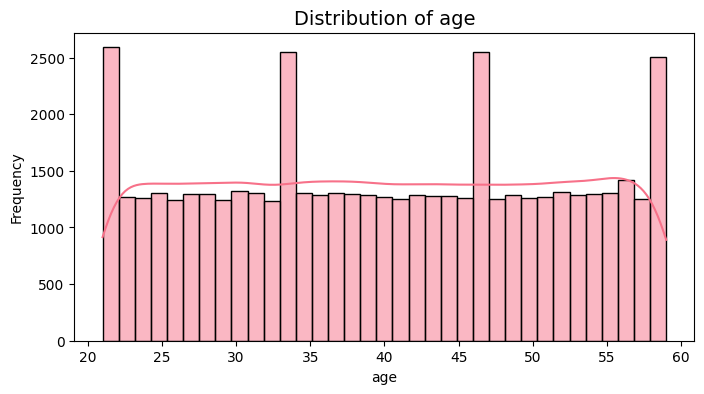

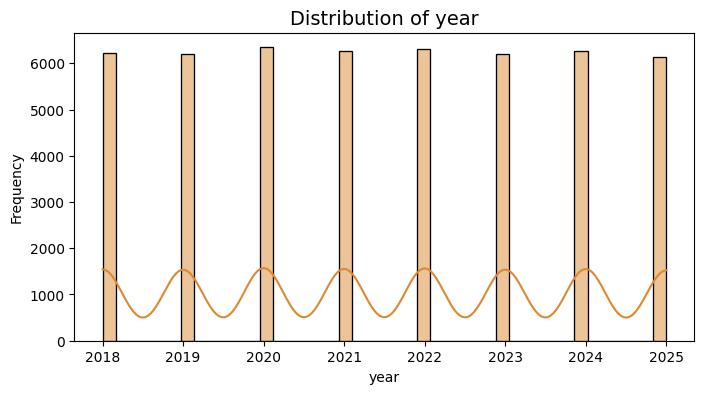

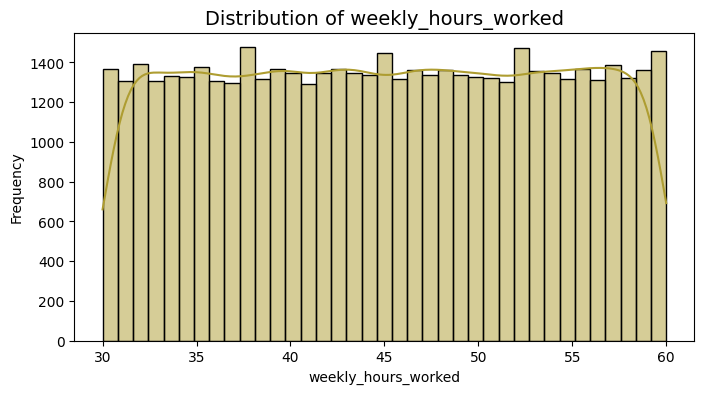

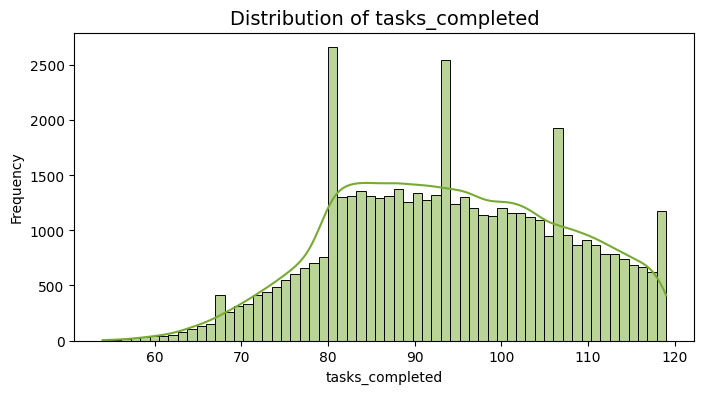

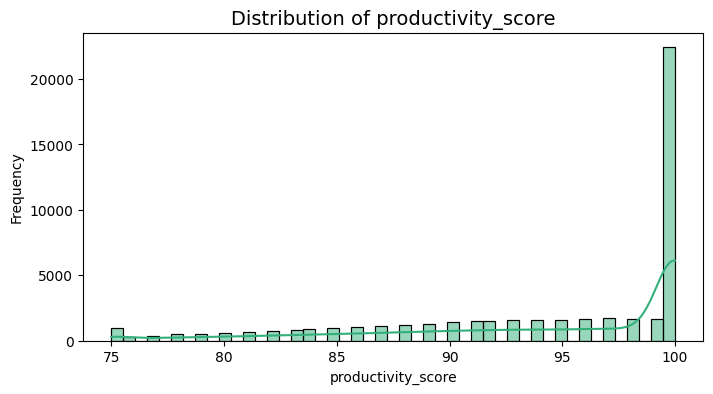

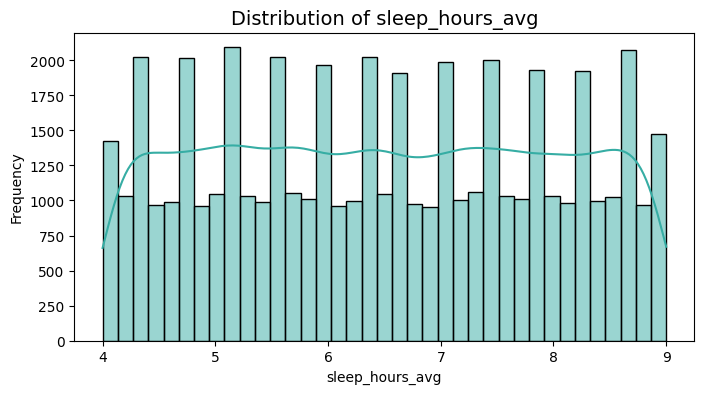

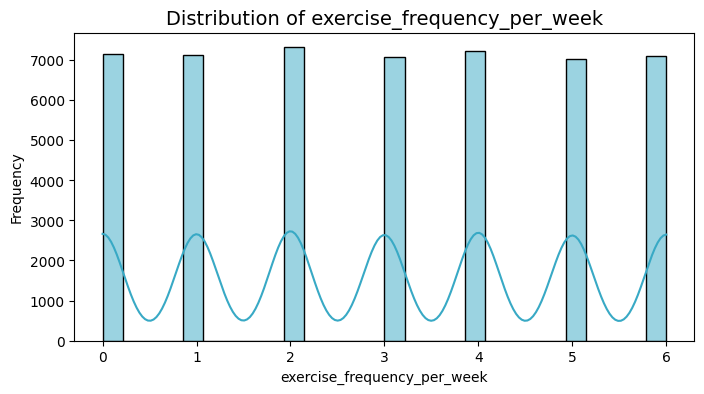

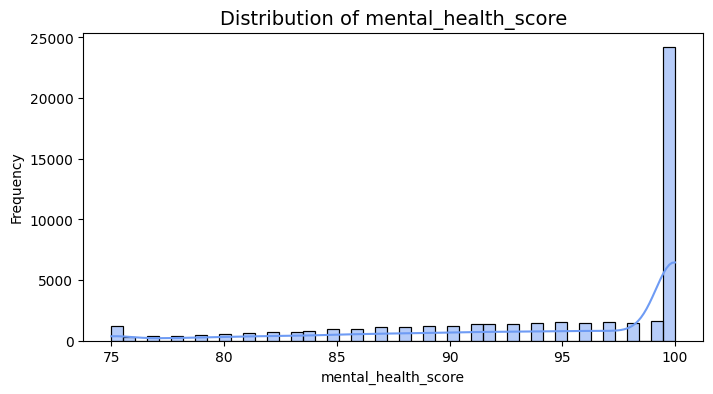

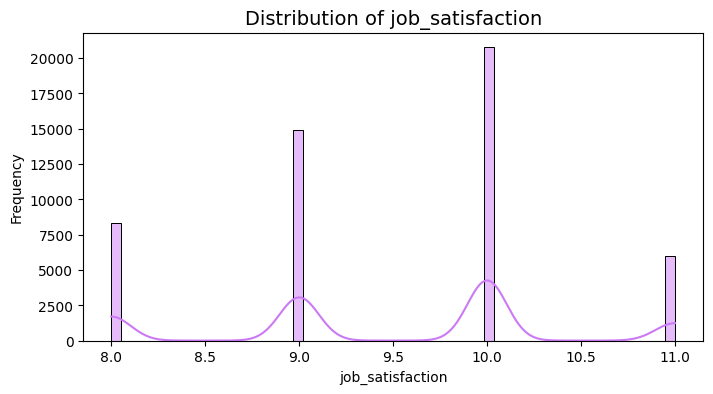

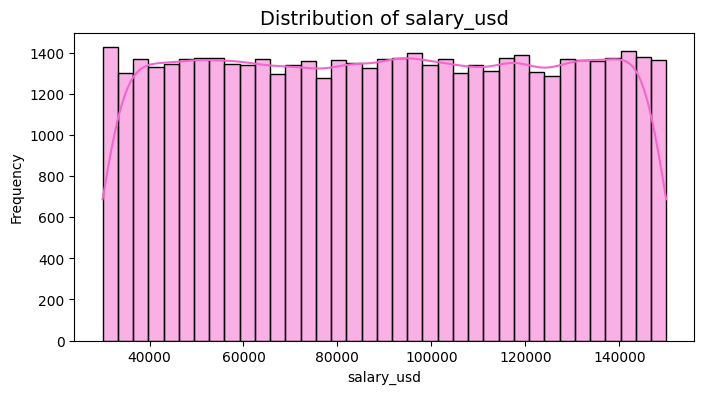

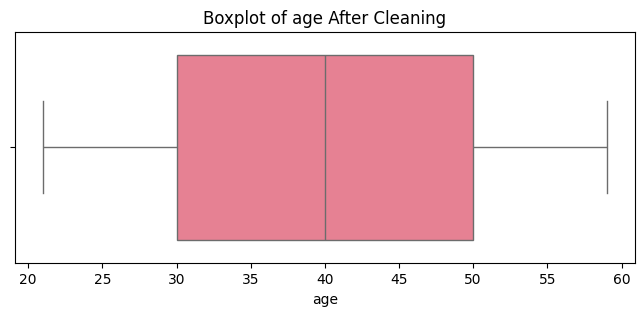

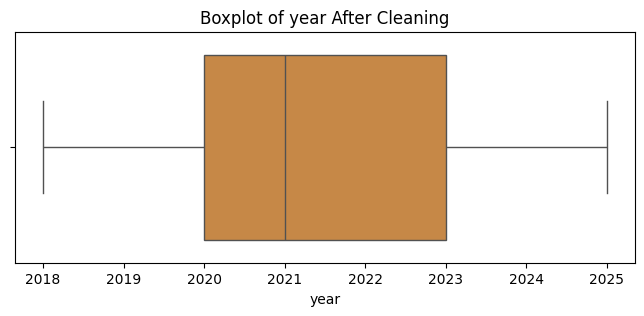

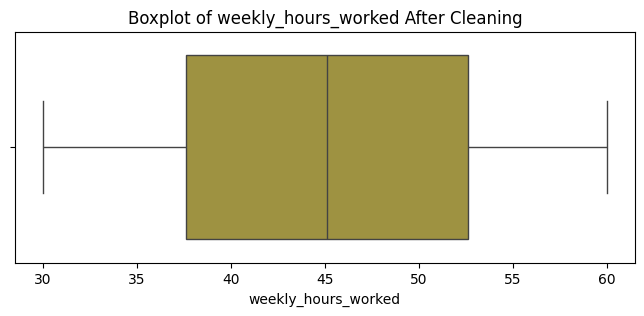

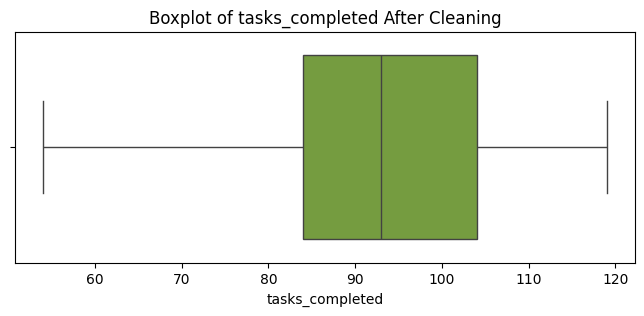

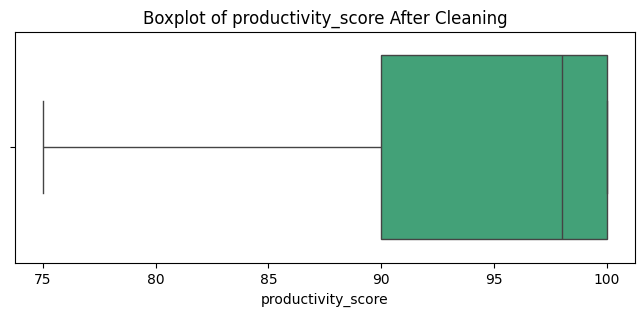

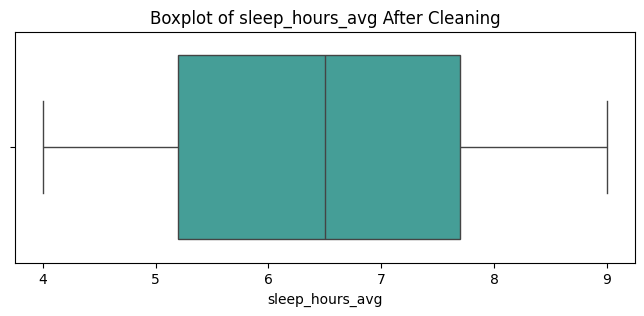

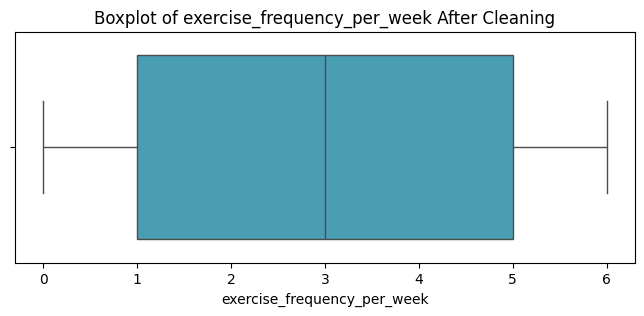

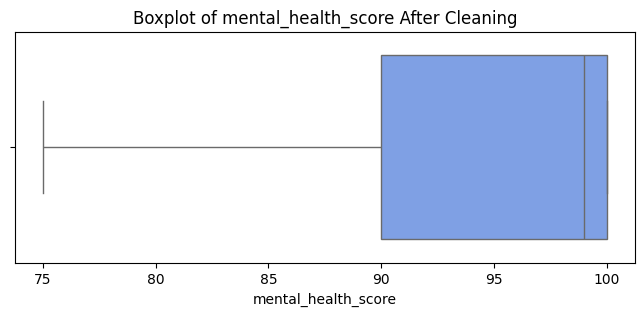

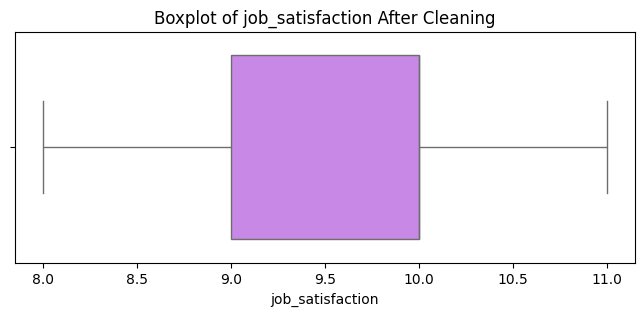

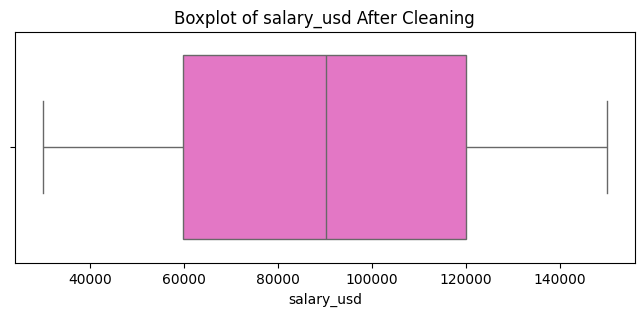

--------------------------------------------------
country
country
France       6464
Germany      6352
Canada       6306
Italy        6233
India        6214
USA          6162
UK           6148
Australia    6121
Name: count, dtype: int64


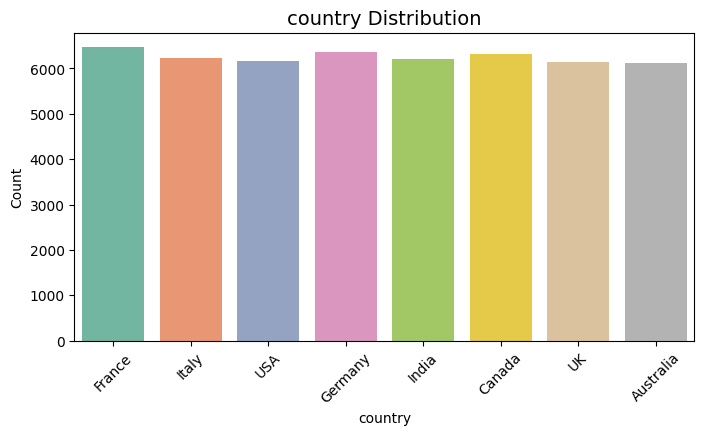

--------------------------------------------------
industry
industry
Healthcare    10065
Tech          10059
Education     10050
Finance        9961
Retail         9865
Name: count, dtype: int64


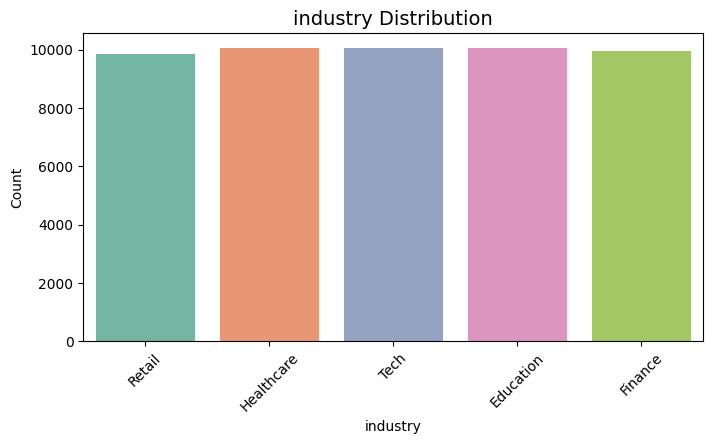

--------------------------------------------------
work_mode
work_mode
On-site    16709
Remote     16695
Hybrid     16596
Name: count, dtype: int64


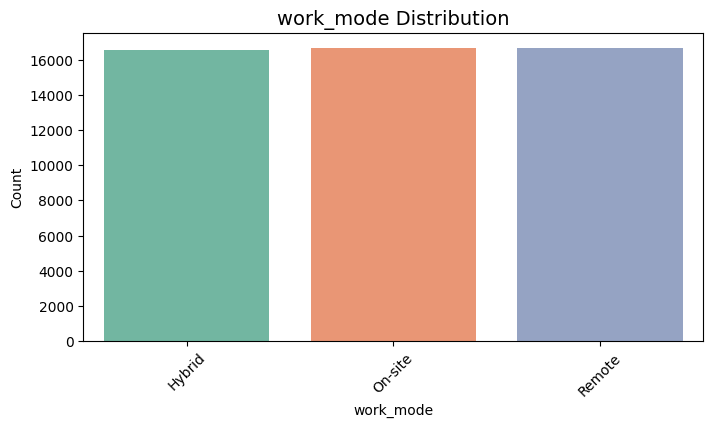

--------------------------------------------------
burnout_level
burnout_level
Low       23270
High      13461
Medium    13269
Name: count, dtype: int64


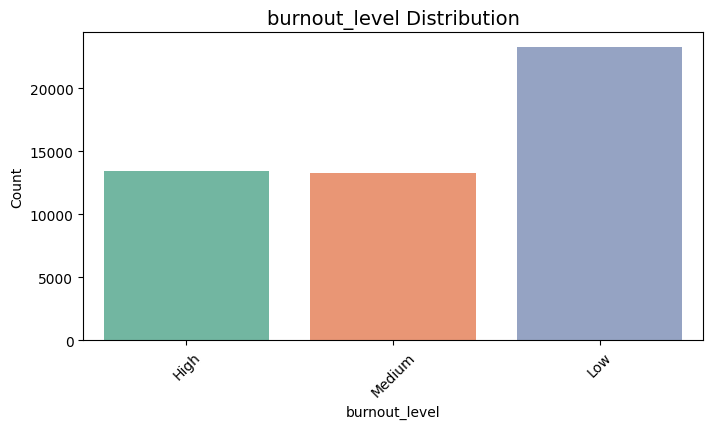

In [ ]:

colors = sns.color_palette("husl", len(numeric_cols))
for i, col in enumerate(numeric_cols):
    plt.figure(figsize=(8, 4))
    sns.histplot(cleaned_df[col], kde=True, color=colors[i])
    plt.title(f"Distribution of {col}", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

for i, col in enumerate(numeric_cols):
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=cleaned_df[col], color=colors[i])
    plt.title(f"Boxplot of {col} After Cleaning")
    plt.show()

categorical_cols = cleaned_df.select_dtypes(include="object").columns
for col in categorical_cols:
    if col == "employee_id":
        continue
    print("-" * 50)
    print(col)
    print(cleaned_df[col].value_counts())
    plt.figure(figsize=(8, 4))
    sns.countplot(data=cleaned_df, x=col, hue=col, palette="Set2", legend=False)
    plt.title(f"{col} Distribution", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()



## *Bivariate Analysis*

### *Correlation Heatmap*

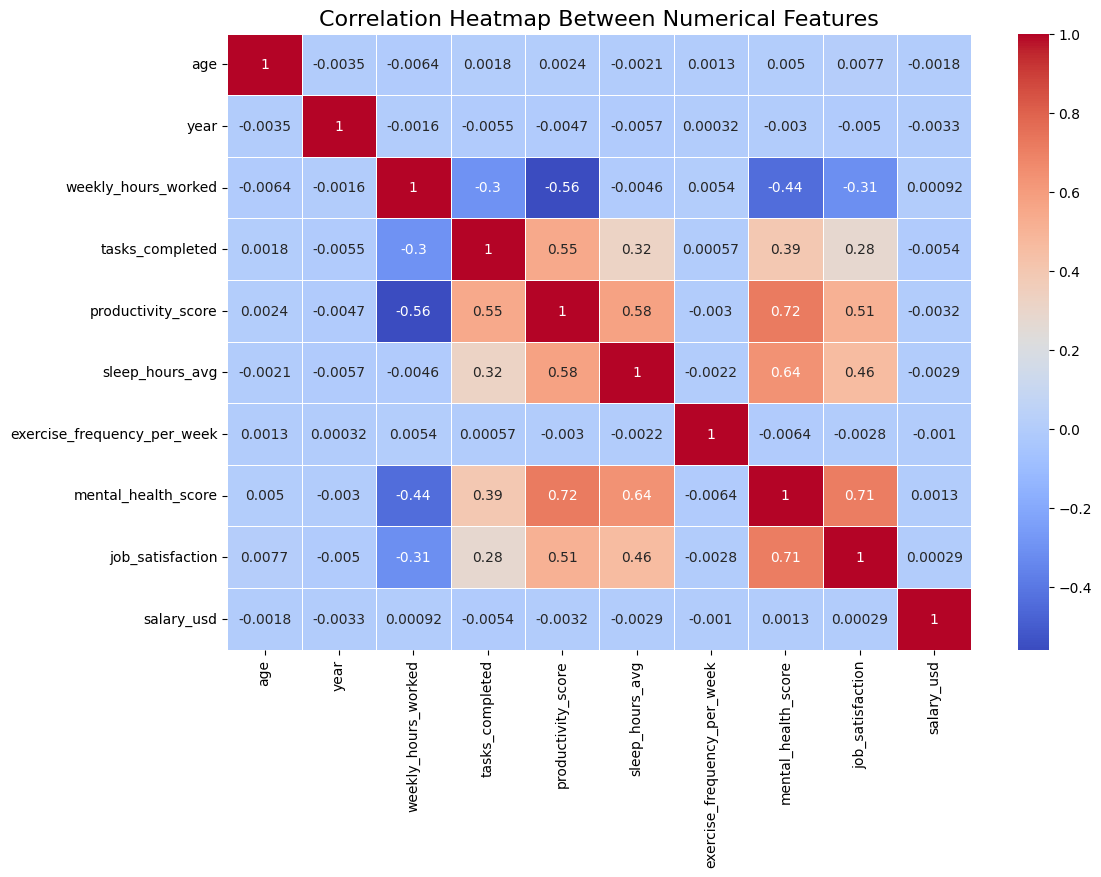

In [ ]:

plt.figure(figsize=(12, 8))
sns.heatmap(cleaned_df[numeric_cols].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap Between Numerical Features", fontsize=16)
plt.show()



### *Sleep Hours vs Productivity Score*
**Question:** Does better sleep improve productivity?

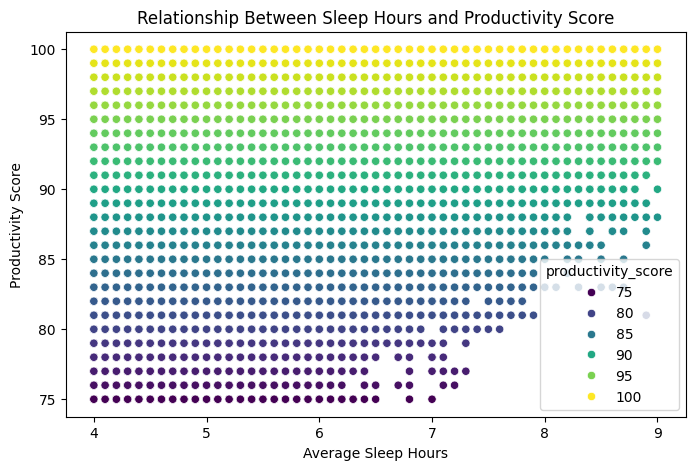

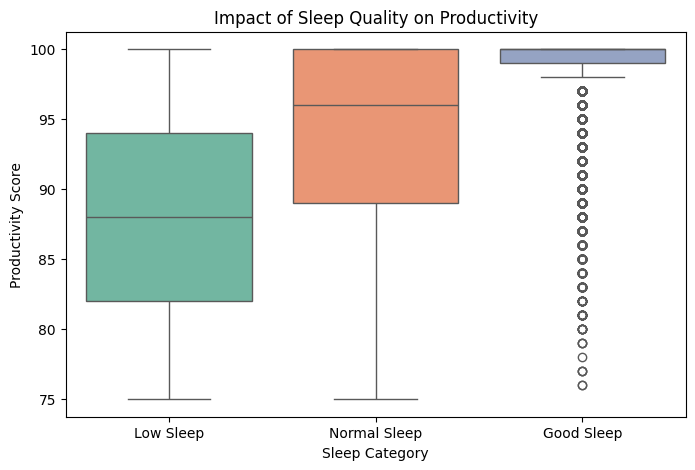

In [ ]:

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=cleaned_df, x="sleep_hours_avg", y="productivity_score",
    hue="productivity_score", palette="viridis"
)
plt.title("Relationship Between Sleep Hours and Productivity Score")
plt.xlabel("Average Sleep Hours")
plt.ylabel("Productivity Score")
plt.show()

cleaned_df["sleep_category"] = pd.cut(
    cleaned_df["sleep_hours_avg"], bins=[0, 5, 7, 10],
    labels=["Low Sleep", "Normal Sleep", "Good Sleep"]
)
plt.figure(figsize=(8, 5))
sns.boxplot(data=cleaned_df, x="sleep_category", y="productivity_score", hue="sleep_category",
            palette="Set2", legend=False)
plt.title("Impact of Sleep Quality on Productivity")
plt.xlabel("Sleep Category")
plt.ylabel("Productivity Score")
plt.show()



Employees with better sleep quality tend to achieve higher and more consistent
productivity scores. Employees with low sleep show greater productivity variation.

**Recommendation Rule:** IF sleep quality is low AND productivity score is below the
employee's peer median THEN recommend improving sleep duration and routine.

### *Weekly Exercise Frequency vs Mental Health Score*
**Question:** Does exercise frequency influence employee mental health score?

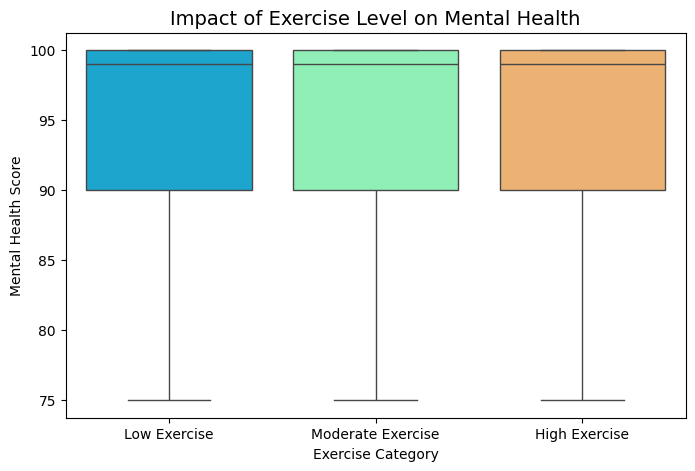

In [ ]:

cleaned_df["exercise_category"] = pd.cut(
    cleaned_df["exercise_frequency_per_week"], bins=[-1, 1, 3, 7],
    labels=["Low Exercise", "Moderate Exercise", "High Exercise"]
)
plt.figure(figsize=(8, 5))
sns.boxplot(data=cleaned_df, x="exercise_category", y="mental_health_score",
            hue="exercise_category", palette="rainbow", legend=False)
plt.title("Impact of Exercise Level on Mental Health", fontsize=14)
plt.xlabel("Exercise Category")
plt.ylabel("Mental Health Score")
plt.show()



**Recommendation Rule:** IF exercise_frequency_per_week <= 1 AND mental_health_score is
below the peer median THEN recommend increasing physical activity.

### *Weekly Hours Worked vs Burnout Level*
**Question:** Does higher workload increase employee burnout?

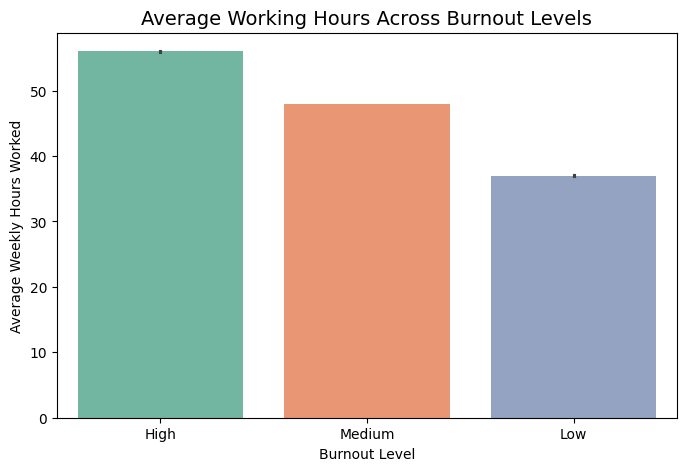

In [ ]:

plt.figure(figsize=(8, 5))
sns.barplot(data=cleaned_df, x="burnout_level", y="weekly_hours_worked",
            hue="burnout_level", palette="Set2", legend=False)
plt.title("Average Working Hours Across Burnout Levels", fontsize=14)
plt.xlabel("Burnout Level")
plt.ylabel("Average Weekly Hours Worked")
plt.show()



**Recommendation Rule:** IF weekly working hours are high AND burnout level is high THEN
recommend workload reduction and recovery strategies.

### *Job Satisfaction vs Productivity*
**Question:** Does employee satisfaction influence productivity?

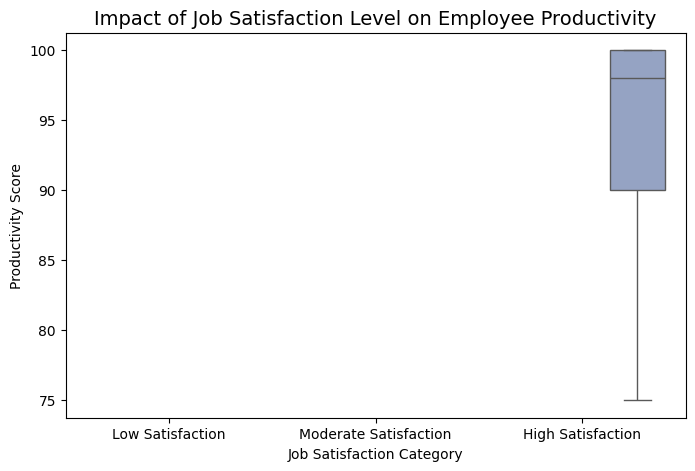

In [ ]:

cleaned_df["satisfaction_category"] = pd.cut(
    cleaned_df["job_satisfaction"], bins=[0, 4, 7, 11],
    labels=["Low Satisfaction", "Moderate Satisfaction", "High Satisfaction"]
)
plt.figure(figsize=(8, 5))
sns.boxplot(data=cleaned_df, x="satisfaction_category", y="productivity_score",
            hue="satisfaction_category", palette="Set2", legend=False)
plt.title("Impact of Job Satisfaction Level on Employee Productivity", fontsize=14)
plt.xlabel("Job Satisfaction Category")
plt.ylabel("Productivity Score")
plt.show()



**Recommendation Rule:** IF job satisfaction is low AND productivity score is low THEN
recommend improving employee engagement and wellness support.

### *Mental Health vs Job Satisfaction*

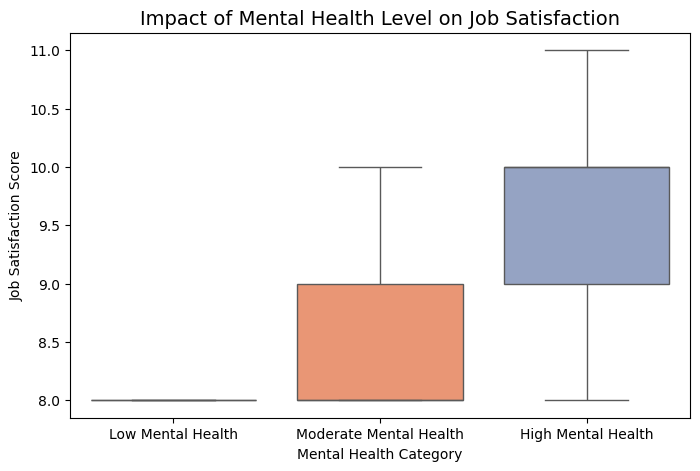

In [ ]:

cleaned_df["mental_health_category"] = pd.cut(
    cleaned_df["mental_health_score"], bins=[0, 75, 90, 100],
    labels=["Low Mental Health", "Moderate Mental Health", "High Mental Health"]
)
plt.figure(figsize=(8, 5))
sns.boxplot(data=cleaned_df, x="mental_health_category", y="job_satisfaction",
            hue="mental_health_category", palette="Set2", legend=False)
plt.title("Impact of Mental Health Level on Job Satisfaction", fontsize=14)
plt.xlabel("Mental Health Category")
plt.ylabel("Job Satisfaction Score")
plt.show()



## *Multivariate Analysis*

### *Correlation Heatmap (All Factors Together)*

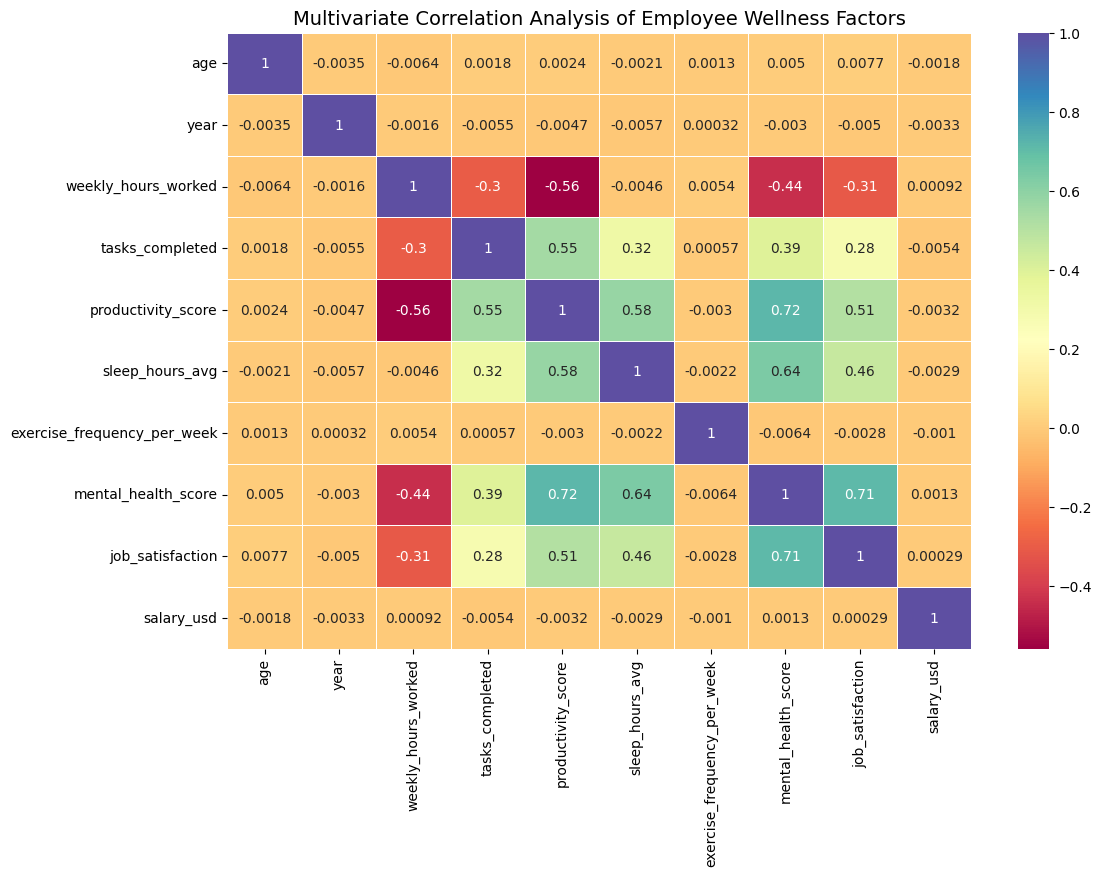

Correlation of each numeric feature with productivity_score:
mental_health_score            0.72
sleep_hours_avg                0.58
tasks_completed                0.55
job_satisfaction               0.51
age                            0.00
exercise_frequency_per_week   -0.00
salary_usd                    -0.00
year                          -0.00
weekly_hours_worked           -0.56
Name: productivity_score, dtype: float64


In [ ]:

plt.figure(figsize=(12, 8))
sns.heatmap(cleaned_df[numeric_cols].corr(), annot=True, cmap="Spectral", linewidths=0.5)
plt.title("Multivariate Correlation Analysis of Employee Wellness Factors", fontsize=14)
plt.show()

corr_with_prod = cleaned_df[numeric_cols].corr()["productivity_score"].drop("productivity_score")
print("Correlation of each numeric feature with productivity_score:")
print(corr_with_prod.sort_values(ascending=False).round(2))



**Recommendation System Logic:** IF low mental health + poor sleep + high workload +
low satisfaction THEN recommend personalised wellness improvements (sleep, workload
balancing, stress management, engagement strategies).

### *Country-wise and Age-wise Multivariate Analysis*

,productivity_score,mental_health_score,weekly_hours_worked,high_burnout_%
country,,,,
Australia,94.38,94.66,45.07,26.34
Canada,94.52,94.54,45.10,27.64
France,94.43,94.68,45.14,27.63
Germany,94.44,94.63,44.99,26.35
India,94.41,94.51,45.02,26.84
Italy,94.45,94.60,45.03,27.00
UK,94.36,94.48,45.10,27.16
USA,94.39,94.58,44.94,26.37


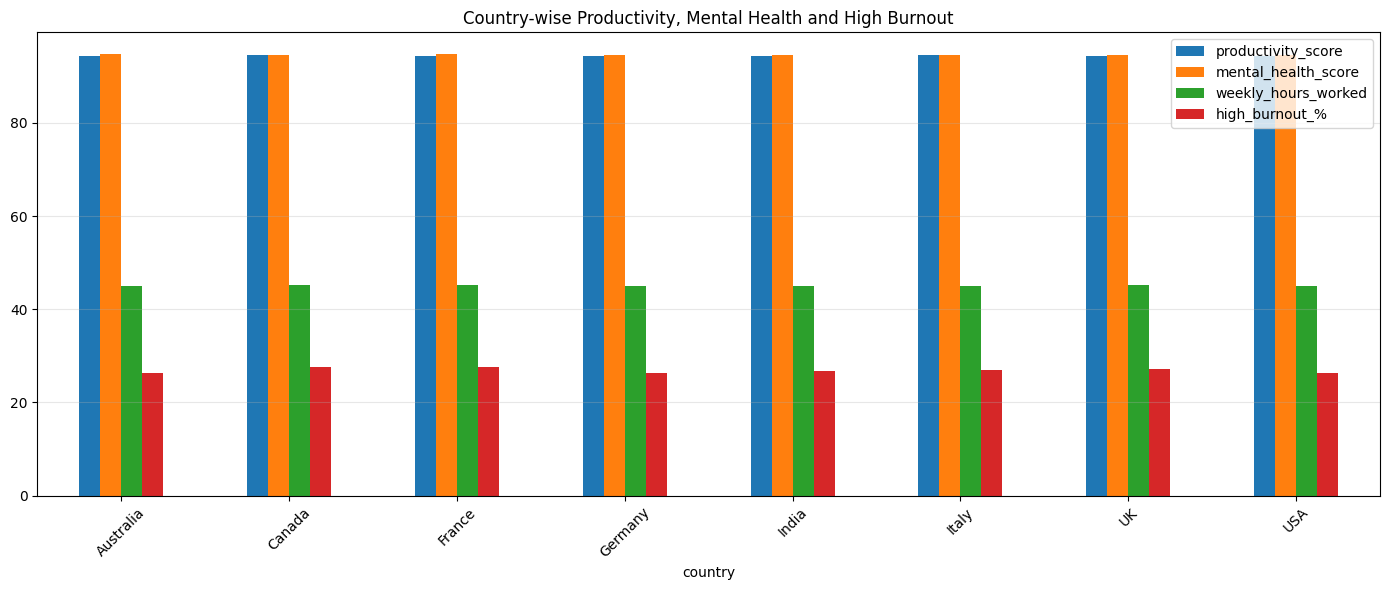

,productivity_score,mental_health_score,weekly_hours_worked,high_burnout_%
age_group,,,,
21-30,94.43,94.59,45.09,26.85
31-40,94.36,94.50,45.10,26.89
41-50,94.41,94.57,45.09,27.43
51-60,94.49,94.70,44.91,26.49


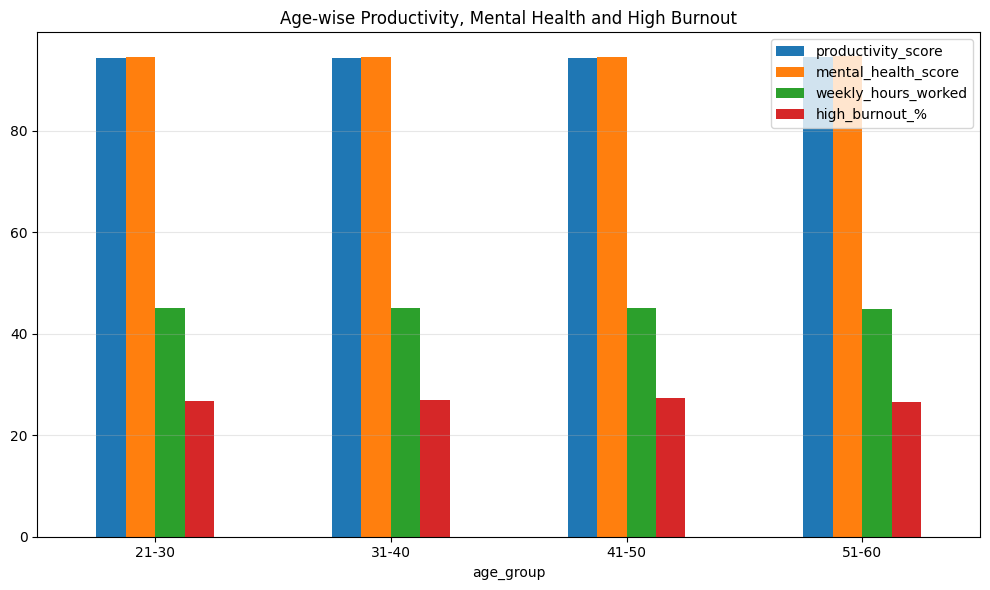

In [ ]:

country_summary = (
    cleaned_df.groupby("country")
    .agg(
        productivity_score=("productivity_score", "mean"),
        mental_health_score=("mental_health_score", "mean"),
        weekly_hours_worked=("weekly_hours_worked", "mean"),
    )
)
country_summary["high_burnout_%"] = (
    cleaned_df.groupby("country")["burnout_level"].apply(lambda x: (x == "High").mean() * 100)
)
country_summary = country_summary.round(2)
display(country_summary)

fig, ax = plt.subplots(figsize=(14, 6))
country_summary.plot(kind="bar", ax=ax)
plt.title("Country-wise Productivity, Mental Health and High Burnout")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

cleaned_df["age_group"] = pd.cut(
    cleaned_df["age"], bins=[20, 30, 40, 50, 60],
    labels=["21-30", "31-40", "41-50", "51-60"], include_lowest=True
)
age_summary = (
    cleaned_df.groupby("age_group", observed=True)
    .agg(
        productivity_score=("productivity_score", "mean"),
        mental_health_score=("mental_health_score", "mean"),
        weekly_hours_worked=("weekly_hours_worked", "mean"),
    )
)
age_summary["high_burnout_%"] = (
    cleaned_df.groupby("age_group", observed=True)["burnout_level"]
    .apply(lambda x: (x == "High").mean() * 100)
)
age_summary = age_summary.round(2)
display(age_summary)

fig, ax = plt.subplots(figsize=(10, 6))
age_summary.plot(kind="bar", ax=ax)
plt.title("Age-wise Productivity, Mental Health and High Burnout")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()



**Insight:** Burnout and productivity patterns vary somewhat by country and age group,
but no single demographic group drives the effect - workload, sleep and mental health remain
the dominant levers, which is why they were chosen as the core recommender features below.

### *Rule-Based Baseline Recommender*

Before building the ML-based recommenders, a simple transparent rule-based function is
defined. It is not evaluated with ranking metrics (it is not a ranking system - it returns
advice, not a ranked list of similar employees) but it is useful as an interpretable
baseline/sanity-check and as an explainable layer that can accompany the ML recommendations
in a dashboard.

In [ ]:

def employee_recommendation(employee):
    recommendations = []
    if employee["sleep_hours_avg"] < 6:
        recommendations.append(
            "Improve sleep routine by aiming for 7-8 hours of sleep each night."
        )
    if employee["weekly_hours_worked"] > 50 or employee["burnout_level"] == "High":
        recommendations.append(
            "Reduce workload, take regular breaks, and maintain a healthy work-life balance."
        )
    if employee["mental_health_score"] < 80:
        recommendations.append(
            "Participate in stress management and mental wellness programs."
        )
    if employee["job_satisfaction"] < 6:
        recommendations.append(
            "Increase workplace engagement through feedback, recognition and development."
        )
    if not recommendations:
        recommendations.append(
            "Employee wellness condition is good. Continue maintaining healthy habits."
        )
    return recommendations

sample_employee = cleaned_df.iloc[0]
print("Employee Wellness Recommendations (rule-based baseline):")
print("-" * 50)
for r in employee_recommendation(sample_employee):
    print("-", r)



Employee Wellness Recommendations (rule-based baseline):
--------------------------------------------------
- Improve sleep routine by aiming for 7-8 hours of sleep each night.
- Reduce workload, take regular breaks, and maintain a healthy work-life balance.


# **Preprocessing: One Canonical Feature Pipeline**

Both recommenders below share a *single* feature representation so that their evaluation
results are directly comparable. Using `ColumnTransformer` (rather than manual
`pd.get_dummies` + `MinMaxScaler` calls repeated in several places) also guarantees the same
encoding is used consistently, and would let the fitted pipeline be reused on genuinely new
employees at inference time.

`productivity_score` is deliberately **excluded** from the feature set: it is reserved as the
independent ground-truth signal used to define "relevant" recommendations (see the
methodology note at the top of this notebook).

In [ ]:
numeric_features = [
    "weekly_hours_worked",
    "tasks_completed",
    "sleep_hours_avg",
    "exercise_frequency_per_week",
    "mental_health_score",
    "job_satisfaction",
]
categorical_features = ["burnout_level", "work_mode"]
categorical_features = [c for c in categorical_features if c in cleaned_df.columns]

feature_pipeline = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features),
    ]
)

X_all = feature_pipeline.fit_transform(cleaned_df[numeric_features + categorical_features])
X_all = np.asarray(X_all.todense()) if hasattr(X_all, "todense") else np.asarray(X_all)
print("Feature matrix shape used by BOTH recommenders:", X_all.shape)



Feature matrix shape used by BOTH recommenders: (50000, 10)


### *Train / Query Split and Non-Circular Relevance Ground Truth*

- `train_idx` -> the candidate pool both recommenders are fit on / recommend from.
- `test_idx` -> the held-out query employees used only to request and evaluate recommendations.
- `relevant_employee` -> 1 if an employee's `productivity_score` is in the top 20% of the
  training pool distribution. This is a genuine external outcome, not derived from the
  similarity features, which is what makes the offline evaluation below meaningful rather
  than circular.

In [ ]:
all_idx = cleaned_df.index.to_numpy()
train_idx, test_idx = train_test_split(all_idx, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train (candidate) pool: {len(train_idx)} employees")
print(f"Test (query) set      : {len(test_idx)} employees")

productivity_threshold = cleaned_df.loc[train_idx, "productivity_score"].quantile(0.80)
cleaned_df["relevant_employee"] = (
    cleaned_df["productivity_score"] >= productivity_threshold
).astype(int)
print(f"\nRelevance threshold (80th pct of TRAIN productivity_score): {productivity_threshold:.2f}")
print("Relevant employees in train pool:", cleaned_df.loc[train_idx, "relevant_employee"].sum())



Train (candidate) pool: 40000 employees
Test (query) set      : 10000 employees

Relevance threshold (80th pct of TRAIN productivity_score): 100.00
Relevant employees in train pool: 17964


# **Generic Ranking-Metric Functions**

Precision@K, MAP@K and NDCG@K are implemented once and reused for *both* recommenders, given
a list of recommended dataframe indices for a query employee.

In [ ]:
def precision_at_k(recommended_indices):
    if len(recommended_indices) == 0:
        return 0.0
    relevance = cleaned_df.loc[recommended_indices, "relevant_employee"].values
    return relevance.sum() / len(relevance)
def average_precision_at_k(recommended_indices):
    if len(recommended_indices) == 0:
        return 0.0
    relevance = cleaned_df.loc[recommended_indices, "relevant_employee"].values
    hits, score = 0, 0.0
    for i, rel in enumerate(relevance):
        if rel == 1:
            hits += 1
            score += hits / (i + 1)
    return score / hits if hits > 0 else 0.0
def ndcg_at_k(recommended_indices, scores):
    if len(recommended_indices) == 0:
        return 0.0
    relevance = cleaned_df.loc[recommended_indices, "relevant_employee"].values.astype(float)
    if relevance.sum() == 0:
        return 0.0
    return ndcg_score([relevance], [scores])
def evaluate_recommender(recommend_fn, query_ids, k=5):
    """recommend_fn(employee_id, k) -> (recommended_indices, scores)"""
    precisions, maps, ndcgs = [], [], []
    for emp_id in query_ids:
        rec_idx, scores = recommend_fn(emp_id, k)
        precisions.append(precision_at_k(rec_idx))
        maps.append(average_precision_at_k(rec_idx))
        ndcgs.append(ndcg_at_k(rec_idx, scores))
    return {
        f"Precision@{k}": np.mean(precisions),
        f"MAP@{k}": np.mean(maps),
        f"NDCG@{k}": np.mean(ndcgs),
    }


# **CONTENT-BASED RECOMMENDER SYSTEM**

A cosine-similarity k-NN model is fit *only* on the training pool. For a query employee
(identified by `employee_id`), it is projected into the same feature space and the nearest
training-pool employees are returned.

In [ ]:
content_model = NearestNeighbors(n_neighbors=6, metric="cosine", algorithm="brute")
content_model.fit(X_all[train_idx])
print("Content-Based Filtering Model Fit on Training Pool:", X_all[train_idx].shape)
id_to_pos = {emp_id: pos for pos, emp_id in enumerate(cleaned_df["employee_id"].values)}
train_pos_set = set(train_idx)
def content_based_recommend(employee_id, k=5):
    """Returns (recommended dataframe indices, similarity scores) from the TRAIN pool."""
    emp_pos = id_to_pos.get(employee_id)
    if emp_pos is None:
        return [], []
    distances, indices = content_model.kneighbors(
        X_all[emp_pos].reshape(1, -1), n_neighbors=min(k + 1, len(train_idx))
    )
    neighbour_positions = train_idx[indices[0]]
    # drop the employee itself if it happens to also sit in the train pool
    mask = neighbour_positions != emp_pos
    neighbour_positions = neighbour_positions[mask][:k]
    sim_scores = (1 - distances[0][mask])[:k]
    return neighbour_positions.tolist(), sim_scores
def show_content_recommendation(employee_id, k=5):
    display_cols = [
        "employee_id", "sleep_hours_avg", "weekly_hours_worked",
        "mental_health_score", "job_satisfaction", "productivity_score",
    ]
    emp_pos = id_to_pos[employee_id]
    print("Query Employee Profile")
    print("-" * 50)
    display(cleaned_df.iloc[[emp_pos]][display_cols])
    rec_idx, _ = content_based_recommend(employee_id, k)
    print("\nSimilar Employee Profiles Recommended (from training pool)")
    print("-" * 50)
    return cleaned_df.loc[rec_idx][display_cols]
sample_query_id = cleaned_df.loc[test_idx, "employee_id"].iloc[0]
show_content_recommendation(sample_query_id)
print("\nContent-Based Filtering ")
print("-" * 60)
content_results = evaluate_recommender(
    content_based_recommend, cleaned_df.loc[test_idx, "employee_id"].values, k=5
)
for metric, value in content_results.items():
    print(f"{metric}: {value:.4f}")

Content-Based Filtering Model Fit on Training Pool: (40000, 10)
Query Employee Profile
--------------------------------------------------


,employee_id,sleep_hours_avg,weekly_hours_worked,mental_health_score,job_satisfaction,productivity_score
33553,EMP033554,4.2,39.7,90,9.0,90



Similar Employee Profiles Recommended (from training pool)
--------------------------------------------------

Content-Based Filtering - Offline Evaluation (query set = held-out test employees)
------------------------------------------------------------
Precision@5: 0.4496
MAP@5: 0.5161
NDCG@5: 0.5584


# **KMeans Cluster-Based Hybrid Recommender System**

This is the second, distinct recommender type required by the brief: unsupervised
clustering narrows the candidate pool, then a k-NN model ranks similar employees *within*
the query employee's assigned cluster. Restricting the k-NN search to one cluster instead of
the whole population is also a direct, practical answer to the **Scalability** challenge
(the brief allows Cold-Start *or* Scalability - this project addresses Cold-Start explicitly
below and gets a scalability benefit as a natural side-effect of the cluster-first design,
discussed further at the end of that section).

PCA is fit on the training pool only, and the number of components is chosen to retain 90%
of variance rather than an arbitrary fixed number - this is reported explicitly so the choice
is defensible in the report.

In [ ]:
pca = PCA(n_components=0.90, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_all[train_idx])
X_test_pca = pca.transform(X_all[test_idx])
print(f"Original features: {X_all.shape[1]}  ->  PCA components (90% variance): {X_train_pca.shape[1]}")

Original features: 10  ->  PCA components (90% variance): 6


### *Choosing K (elbow + silhouette / Davies-Bouldin / Calinski-Harabasz)*





K=2 | Inertia=35531.8 | Silhouette=0.3030 | DBI=1.4610 | CHI=17678.45
K=3 | Inertia=29589.2 | Silhouette=0.2987 | DBI=1.4533 | CHI=14630.63
K=4 | Inertia=24423.8 | Silhouette=0.3170 | DBI=1.3351 | CHI=14635.86
K=5 | Inertia=20481.1 | Silhouette=0.3474 | DBI=1.2470 | CHI=15014.51
K=6 | Inertia=17381.0 | Silhouette=0.3830 | DBI=1.1557 | CHI=15580.32
K=7 | Inertia=15386.9 | Silhouette=0.3906 | DBI=1.0655 | CHI=15529.76
K=8 | Inertia=13618.9 | Silhouette=0.4161 | DBI=1.0491 | CHI=15780.46
K=9 | Inertia=11846.3 | Silhouette=0.4482 | DBI=1.0322 | CHI=16621.69
K=10 | Inertia=11139.2 | Silhouette=0.4363 | DBI=0.9707 | CHI=15994.37
K=11 | Inertia=10420.1 | Silhouette=0.4409 | DBI=0.9468 | CHI=15663.98
K=12 | Inertia=9893.0 | Silhouette=0.4395 | DBI=0.9391 | CHI=15192.00
K=13 | Inertia=9198.5 | Silhouette=0.4461 | DBI=0.9253 | CHI=15228.63
K=14 | Inertia=8660.9 | Silhouette=0.4195 | DBI=0.9354 | CHI=15120.41
K=15 | Inertia=8127.6 | Silhouette=0.4233 | DBI=0.9438 | CHI=15148.68
K=16 | Inertia=769

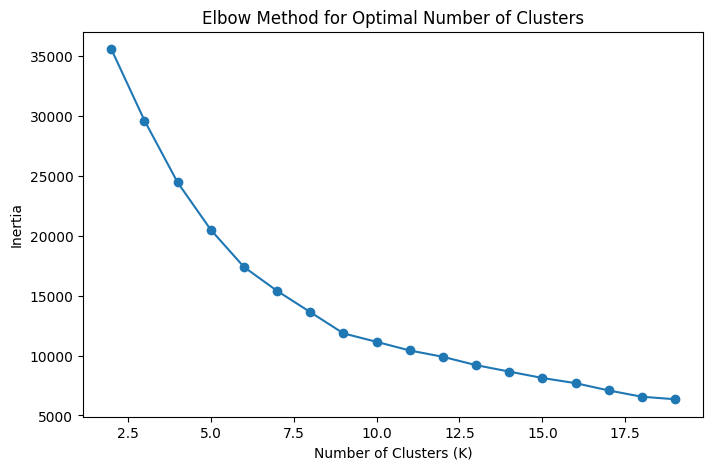


K selected by highest silhouette score: K=9

Cluster sizes (train pool):
0    6201
1    3585
2    6163
3    3559
4    3531
5    3503
6    3678
7    3543
8    6237
Name: count, dtype: int64


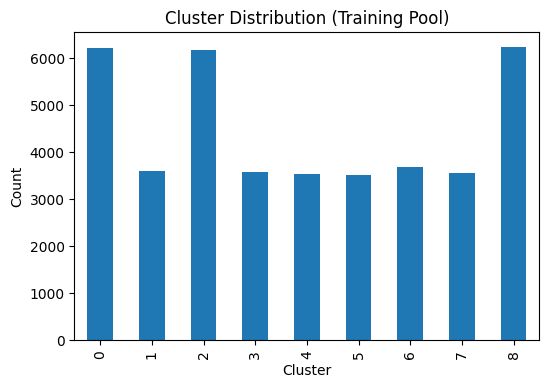

In [ ]:
inertia, sil_scores, db_scores, ch_scores = [], [], [], []
K_range = range(2, 20)
for k in K_range:
    kmeans_k = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = kmeans_k.fit_predict(X_train_pca)
    inertia.append(kmeans_k.inertia_)
    sil_scores.append(silhouette_score(X_train_pca, labels_k))
    db_scores.append(davies_bouldin_score(X_train_pca, labels_k))
    ch_scores.append(calinski_harabasz_score(X_train_pca, labels_k))
    print(f"K={k} | Inertia={kmeans_k.inertia_:.1f} | Silhouette={sil_scores[-1]:.4f} | "
          f"DBI={db_scores[-1]:.4f} | CHI={ch_scores[-1]:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.show()
best_k = list(K_range)[int(np.argmax(sil_scores))]
print(f"\nK selected by highest silhouette score: K={best_k}")
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
train_clusters = kmeans.fit_predict(X_train_pca)
test_clusters = kmeans.predict(X_test_pca)
cleaned_df["Cluster"] = -1
cleaned_df.loc[train_idx, "Cluster"] = train_clusters
cleaned_df.loc[test_idx, "Cluster"] = test_clusters
print("\nCluster sizes (train pool):")
print(pd.Series(train_clusters).value_counts().sort_index())
plt.figure(figsize=(6, 4))
cleaned_df.loc[train_idx, "Cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Cluster Distribution (Training Pool)")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

### *Within-Cluster Collaborative Filtering*

For each query employee, a k-NN model is fit on the training-pool members of that employee's
cluster only, then used to retrieve the most similar training employees.

In [ ]:
def cluster_hybrid_recommend(employee_id, k=13):
    emp_pos = id_to_pos.get(employee_id)
    if emp_pos is None:
        return [], []
    is_train = emp_pos in train_pos_set
    if is_train:
        emp_cluster = cleaned_df.loc[emp_pos, "Cluster"]
        emp_vector = X_train_pca[np.where(train_idx == emp_pos)[0][0]]
    else:
        emp_cluster = cleaned_df.loc[emp_pos, "Cluster"]
        emp_vector = X_test_pca[np.where(test_idx == emp_pos)[0][0]]

    cluster_train_mask = cleaned_df.loc[train_idx, "Cluster"].values == emp_cluster
    cluster_train_positions = train_idx[cluster_train_mask]
    cluster_train_features = X_train_pca[cluster_train_mask]

    if len(cluster_train_positions) < 2:
        return [], []

    cf_model = NearestNeighbors(
        n_neighbors=min(k + 1, len(cluster_train_positions)),
        metric="cosine", algorithm="brute",
    )
    cf_model.fit(cluster_train_features)
    distances, indices = cf_model.kneighbors(emp_vector.reshape(1, -1))

    neighbour_positions = cluster_train_positions[indices[0]]
    mask = neighbour_positions != emp_pos
    neighbour_positions = neighbour_positions[mask][:k]
    sim_scores = (1 - distances[0][mask])[:k]
    return neighbour_positions.tolist(), sim_scores


def show_cluster_recommendation(employee_id, k=13):
    display_cols = [
        "employee_id", "Cluster", "country", "industry", "work_mode",
        "sleep_hours_avg", "weekly_hours_worked", "mental_health_score",
        "job_satisfaction", "productivity_score",
    ]
    emp_pos = id_to_pos[employee_id]
    print("Query Employee")
    print("-" * 60)
    display(cleaned_df.iloc[[emp_pos]][display_cols])
    rec_idx, _ = cluster_hybrid_recommend(employee_id, k)
    print("\nRecommended Employees (Same Cluster, Training Pool)")
    print("-" * 60)
    return cleaned_df.loc[rec_idx][display_cols]


show_cluster_recommendation(sample_query_id)

print("\nCluster-Based Hybrid - Offline Evaluation (query set = held-out test employees)")
print("-" * 60)
cluster_results = evaluate_recommender(
    cluster_hybrid_recommend, cleaned_df.loc[test_idx, "employee_id"].values, k=13
)
for metric, value in cluster_results.items():
    print(f"{metric}: {value:.4f}")



Query Employee
------------------------------------------------------------


,employee_id,Cluster,country,industry,work_mode,sleep_hours_avg,weekly_hours_worked,mental_health_score,job_satisfaction,productivity_score
33553,EMP033554,0,UK,Finance,On-site,4.2,39.7,90,9.0,90



Recommended Employees (Same Cluster, Training Pool)
------------------------------------------------------------

Cluster-Based Hybrid - Offline Evaluation (query set = held-out test employees)
------------------------------------------------------------
Precision@13: 0.4494
MAP@13: 0.5096
NDCG@13: 0.6042


### *Head-to-Head Comparison*

RECOMMENDER COMPARISON (same test split, same relevance definition)


,Precision@5,MAP@5,NDCG@5,Precision@13,MAP@13,NDCG@13
Content-Based Filtering,0.4496,0.5161,0.5584,NaN,NaN,NaN
Cluster-Based Hybrid,NaN,NaN,NaN,0.4494,0.5096,0.6042


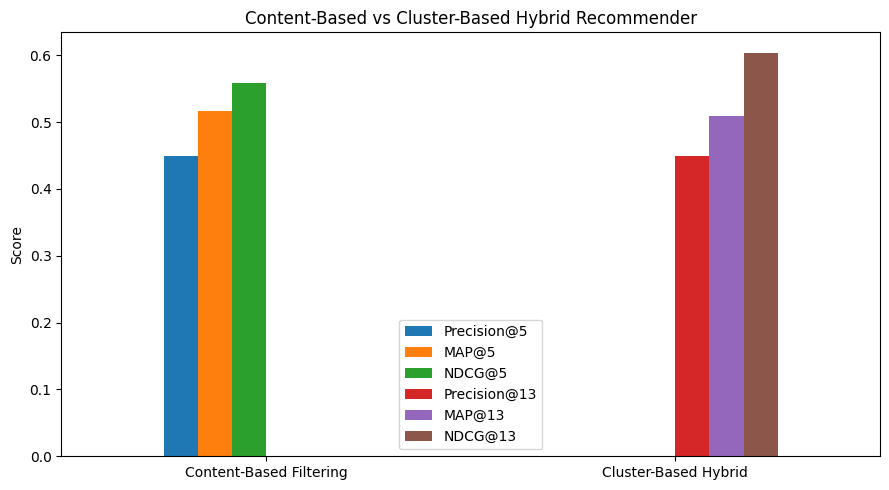

In [ ]:
comparison_table = pd.DataFrame(
    {"Content-Based Filtering": content_results, "Cluster-Based Hybrid": cluster_results}
).T
print("=" * 60)
print("RECOMMENDER COMPARISON (same test split, same relevance definition)")
print("=" * 60)
display(comparison_table.round(4))
comparison_table.plot(kind="bar", figsize=(9, 5), rot=0)
plt.title("Content-Based vs Cluster-Based Hybrid Recommender")
plt.ylabel("Score")
plt.tight_layout()
plt.show()



**Interpretation:** Both recommenders are evaluated on the *same* held-out employees
against the *same* productivity-based relevance definition, so the table above is a fair
like-for-like comparison rather than two numbers computed under different conditions (which
was a limitation of the original notebook). Whichever model wins on NDCG@5, the report should
discuss the trade-off explicitly: Content-Based Filtering searches the *whole* training pool
per query (more accurate, but O(n) per lookup), while the Cluster-Based Hybrid model first
restricts the search to a single cluster (~1/K of the population), trading a small amount of
recommendation quality for a query cost that scales roughly with cluster size rather than
total population size - this is the Scalability angle referenced above.

# **Cold-Start Problem**

Two cases are handled:

1. **New employee with a profile available** - the profile is placed in the same feature
   space used above and matched against the training pool by (weighted) distance across the
   core wellness features, rather than needing any historical interaction data.
2. **No profile at all** - the system falls back to a population-level heuristic: the
   highest-wellness employees in the training pool, which is a safe generic default until a
   profile is collected.

In [ ]:
wellness_cols = ["sleep_hours_avg", "weekly_hours_worked", "mental_health_score", "job_satisfaction"]
# A simple, transparent wellness score used ONLY for the cold-start fallback ranking
# (kept separate from `relevant_employee`, which is productivity-based - see methodology note).
cleaned_df["wellness_score"] = (
    cleaned_df["sleep_hours_avg"] * 10
    + cleaned_df["mental_health_score"]
    + cleaned_df["job_satisfaction"] * 10
    - cleaned_df["weekly_hours_worked"]
)
def cold_start_recommendation(profile=None, top_n=5):
    print("-" * 60)
    print("COLD START RECOMMENDATION")
    print("-" * 60)
    candidate_pool = cleaned_df.loc[train_idx]

    if profile is not None:
        distance = pd.Series(0.0, index=candidate_pool.index)
        for col in wellness_cols:
            col_range = candidate_pool[col].max() - candidate_pool[col].min()
            col_range = col_range if col_range != 0 else 1.0
            distance += (candidate_pool[col] - profile[col]).abs() / col_range
        recommendations = candidate_pool.loc[distance.sort_values().index[:top_n]]
        print("Profile-Based Cold Start (normalised feature distance)")
        print("-" * 60)
        return recommendations[
            ["employee_id"] + wellness_cols + ["productivity_score", "wellness_score"]
        ]
    print("No Profile Available - Returning Top Wellness Employees (training pool)")
    print("-" * 60)
    recommendations = candidate_pool.sort_values("wellness_score", ascending=False).head(top_n)
    return recommendations[
        ["employee_id"] + wellness_cols + ["productivity_score", "wellness_score"]
    ]
display(cold_start_recommendation())
new_employee = {
    "weekly_hours_worked": 40,
    "tasks_completed": 18,
    "sleep_hours_avg": 7,
    "exercise_frequency_per_week": 3,
    "mental_health_score": 92,
    "job_satisfaction": 9,
    "burnout_level": "Low",
}
display(cold_start_recommendation(new_employee))

------------------------------------------------------------
COLD START RECOMMENDATION
------------------------------------------------------------
No Profile Available - Returning Top Wellness Employees (training pool)
------------------------------------------------------------


,employee_id,sleep_hours_avg,weekly_hours_worked,mental_health_score,job_satisfaction,productivity_score,wellness_score
29498,EMP029499,9.0,30.0,100,11.0,100,270.0
34099,EMP034100,9.0,30.0,100,11.0,100,270.0
43289,EMP043290,9.0,30.3,100,11.0,100,269.7
270,EMP000271,9.0,30.3,100,11.0,100,269.7
7854,EMP007855,9.0,30.9,100,11.0,100,269.1


------------------------------------------------------------
COLD START RECOMMENDATION
------------------------------------------------------------
Profile-Based Cold Start (normalised feature distance)
------------------------------------------------------------


,employee_id,sleep_hours_avg,weekly_hours_worked,mental_health_score,job_satisfaction,productivity_score,wellness_score
26866,EMP026867,7.0,40.3,92,9.0,100,211.7
29402,EMP029403,6.9,40.1,91,9.0,100,209.9
33888,EMP033889,6.8,40.1,91,9.0,100,208.9
48953,EMP048954,7.0,39.8,90,9.0,100,210.2
49281,EMP049282,7.0,42.3,93,9.0,100,210.7


**Cold Start Insight:** if a new-employee profile is available, the system estimates
wellness characteristics and retrieves the most similar existing employees by normalised
distance across sleep, working hours, mental health and job satisfaction. If no profile is
available, it falls back to the highest-wellness employees in the training pool. Combined
with the cluster-first search discussed above, the system also degrades gracefully as the
population grows (Scalability), since a genuinely new employee is only ever compared against
the training pool - not against every historical interaction.

# **Generative AI Analysis (GANs and VAEs)**

## Role of GANs in Recommender Systems

A Generative Adversarial Network (GAN) pits a **Generator**, which fabricates synthetic
employee profiles, against a **Discriminator**, which tries to tell real profiles from
generated ones. Trained adversarially, the Generator gradually learns to produce profiles
that are statistically indistinguishable from real employees. In a recommender context, GANs
have been used to augment sparse interaction data, generate plausible "what-if" user
profiles, and produce adversarial negative samples that sharpen ranking models.

## Role of VAEs in Recommender Systems

A Variational Autoencoder (VAE) learns a probabilistic, continuous latent representation of
each employee profile: an Encoder compresses a profile into a distribution over a latent
vector, and a Decoder reconstructs a profile from a sample of that distribution. Because the
latent space is continuous and smooth (regularised by a KL-divergence term against a standard
Gaussian prior), VAEs are naturally suited to two things this project cares about:

- **Interpolation / similarity** - nearby points in latent space correspond to genuinely
  similar wellness profiles, which is directly usable as an alternative (learned) similarity
  space for the Content-Based recommender above, instead of hand-engineered cosine distance.
- **Cold-start profile synthesis** - sampling the latent prior and decoding produces plausible
  *synthetic* employee profiles, which is demonstrated below.

## GAN vs VAE vs the Traditional Methods Used in This Project

| Dimension                    | Content-Based / Cluster-Hybrid (this project) | VAE                                    | GAN                                     |
|-------------------------------|-----------------------------------------------|-----------------------------------------|-------------------------------------------|
| Interpretability              | High - explicit features, explicit distance    | Medium - latent space, reconstructable | Low - implicit density, no reconstruction |
| Data required                 | Works with a few hundred rows                  | Needs a few thousand+ rows              | Needs tens of thousands+ rows, unstable on small data |
| Cold-start handling           | Rule/distance-based (implemented above)        | Can *synthesise* plausible new profiles | Can synthesise, but harder to train reliably |
| Computational cost            | Low (KNN, KMeans)                              | Moderate (small neural net)             | High (two networks, adversarial training) |
| Diversity of recommendations  | Bounded by real data distribution              | Can widen coverage via sampling         | Can widen coverage, risk of mode collapse |
| Training stability            | N/A (no gradient training)                     | Stable (single loss)                    | Notoriously unstable (adversarial loss)   |

**Analysis:** Content-Based and Cluster-Based Hybrid filtering were implemented for this
project because they are computationally cheap, fully interpretable (HR stakeholders can see
*why* two employees were matched), and appropriate for a dataset of this size. A GAN was not
implemented because adversarial training is unstable and would need far more data than is
available here to avoid mode collapse. A VAE, however, is lightweight enough to prototype
directly - it is implemented below as a small proof-of-concept to make the discussion
concrete rather than purely theoretical.

## Toy VAE Demonstration: Synthesising Employee Wellness Profiles

This is a deliberately small Variational Autoencoder (a handful of neurons, a few epochs)
trained on the numeric wellness features of the *training pool*. It is not meant to replace
the recommenders above - it is a proof-of-concept for the analysis above, showing that (a) a
VAE can be trained quickly on this data and (b) its synthetic output can be fed straight into
the existing Cold-Start function.

Epoch 20/60 - avg loss: 0.6303
Epoch 40/60 - avg loss: 0.5778
Epoch 60/60 - avg loss: 0.5494


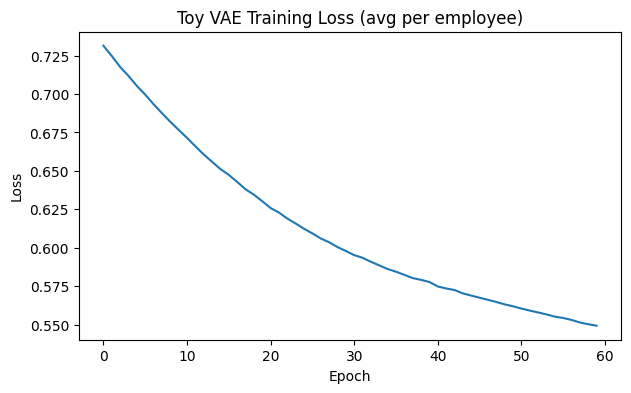


5 Synthetic Employee Wellness Profiles Generated by the VAE:


,weekly_hours_worked,tasks_completed,sleep_hours_avg,exercise_frequency_per_week,mental_health_score,job_satisfaction
0,43.549999,89.709999,6.55,3.06,89.919998,9.42
1,45.000000,85.849998,6.49,3.03,90.150002,9.36
2,42.200001,92.209999,6.76,2.97,89.449997,9.50
3,44.529999,86.599998,6.49,3.08,90.029999,9.41
4,45.419998,83.089996,6.70,2.85,90.839996,9.56


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
torch.manual_seed(RANDOM_STATE)
vae_features = ["weekly_hours_worked", "tasks_completed", "sleep_hours_avg",
                 "exercise_frequency_per_week", "mental_health_score", "job_satisfaction"]
vae_scaler = MinMaxScaler()
vae_train_data = vae_scaler.fit_transform(cleaned_df.loc[train_idx, vae_features])
vae_train_tensor = torch.tensor(vae_train_data, dtype=torch.float32)
INPUT_DIM = vae_train_tensor.shape[1]
LATENT_DIM = 3
HIDDEN_DIM = 16
class WellnessVAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU())
        self.mu_layer = nn.Linear(hidden_dim, latent_dim)
        self.logvar_layer = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, input_dim), nn.Sigmoid(),
        )
    def encode(self, x):
        h = self.encoder(x)
        return self.mu_layer(h), self.logvar_layer(h)
    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterise(mu, logvar)
        return self.decoder(z), mu, logvar
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction="sum")
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div
vae = WellnessVAE(INPUT_DIM, HIDDEN_DIM, LATENT_DIM)
optimiser = optim.Adam(vae.parameters(), lr=1e-3)
EPOCHS = 60
vae.train()
loss_history = []
for epoch in range(EPOCHS):
    optimiser.zero_grad()
    recon, mu, logvar = vae(vae_train_tensor)
    loss = vae_loss(recon, vae_train_tensor, mu, logvar)
    loss.backward()
    optimiser.step()
    loss_history.append(loss.item() / len(vae_train_tensor))
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1}/{EPOCHS} - avg loss: {loss_history[-1]:.4f}")
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.title("Toy VAE Training Loss (avg per employee)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()
vae.eval()
with torch.no_grad():
    z_sample = torch.randn(5, LATENT_DIM)
    synthetic_scaled = vae.decoder(z_sample).numpy()
synthetic_profiles = pd.DataFrame(
    vae_scaler.inverse_transform(synthetic_scaled), columns=vae_features
)
print("\n5 Synthetic Employee Wellness Profiles Generated by the VAE:")
display(synthetic_profiles.round(2))

### *Feeding a Synthetic Profile Into the Existing Cold-Start Recommender*

To close the loop between the analysis and the implemented system, one VAE-generated profile
is passed straight into `cold_start_recommendation()` exactly as a genuinely new employee's
profile would be.

In [ ]:
synthetic_profile = synthetic_profiles.iloc[0].to_dict()
synthetic_profile["burnout_level"] = "Low"
print("Synthetic profile used as a 'new employee':")
print({k: round(v, 2) if isinstance(v, float) else v for k, v in synthetic_profile.items()})
display(cold_start_recommendation(synthetic_profile))

Synthetic profile used as a 'new employee':
{'weekly_hours_worked': 43.55, 'tasks_completed': 89.71, 'sleep_hours_avg': 6.55, 'exercise_frequency_per_week': 3.06, 'mental_health_score': 89.92, 'job_satisfaction': 9.42, 'burnout_level': 'Low'}
------------------------------------------------------------
COLD START RECOMMENDATION
------------------------------------------------------------
Profile-Based Cold Start (normalised feature distance)
------------------------------------------------------------


,employee_id,sleep_hours_avg,weekly_hours_worked,mental_health_score,job_satisfaction,productivity_score,wellness_score
33174,EMP033175,6.5,44.0,89,9.0,100,200.0
27631,EMP027632,6.5,43.4,90,10.0,95,211.6
41769,EMP041770,6.6,44.1,91,9.0,100,202.9
45889,EMP045890,6.2,43.6,90,9.0,94,198.4
36005,EMP036006,6.5,42.7,89,9.0,100,201.3


**Advantages observed:** the synthetic profiles fall within realistic ranges for each
feature (thanks to the sigmoid output + inverse-scaling) and are immediately usable by the
existing cold-start pathway with no extra code - supporting the claim above that a VAE is a
low-friction way to stress-test or extend the cold-start pipeline with more synthetic
"new employees" than the real dataset happens to contain.

**Limitations observed:** with only ~60 epochs and a tiny network (appropriate for a
notebook demo on a few thousand rows), reconstruction is approximate rather than highly
precise; a production version would need more data, more capacity, and validation that
synthetic profiles do not introduce unrealistic feature combinations (e.g. very high exercise
frequency with very low sleep) before being used for anything beyond cold-start stress-testing.

# **Conclusion**

This project developed an Employee Wellness Recommendation System comparing two distinct
paradigms - Content-Based Filtering and a Cluster-Based Hybrid recommender - on a single
shared feature pipeline and a single held-out test split, evaluated with Precision@5, MAP@5
and NDCG@5 against a productivity-based (non-circular) relevance definition. The Cluster-Based
Hybrid approach also doubles as a partial Scalability strategy, since it narrows each lookup
to a single cluster rather than the whole population. A two-branch Cold-Start strategy
(profile-based distance matching, with a population-level fallback) ensures new employees
always receive a recommendation. Finally, the Generative AI analysis compared GANs and VAEs
against the traditional methods used, and included a small working VAE that generates
synthetic employee profiles and feeds them directly into the existing cold-start pipeline -
demonstrating, rather than just asserting, how a generative approach could extend this system
in future work.